Reading dataset from: C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv

=== CLASS DISTRIBUTION ANALYSIS ===
Class 0 [Nominal (Normal)]: 1221 samples (61.1%)
Class 1 [Freeze Attack]: 395 samples (19.8%)
Class 2 [Replay Attack]: 384 samples (19.2%)

Generating visual signature plots...


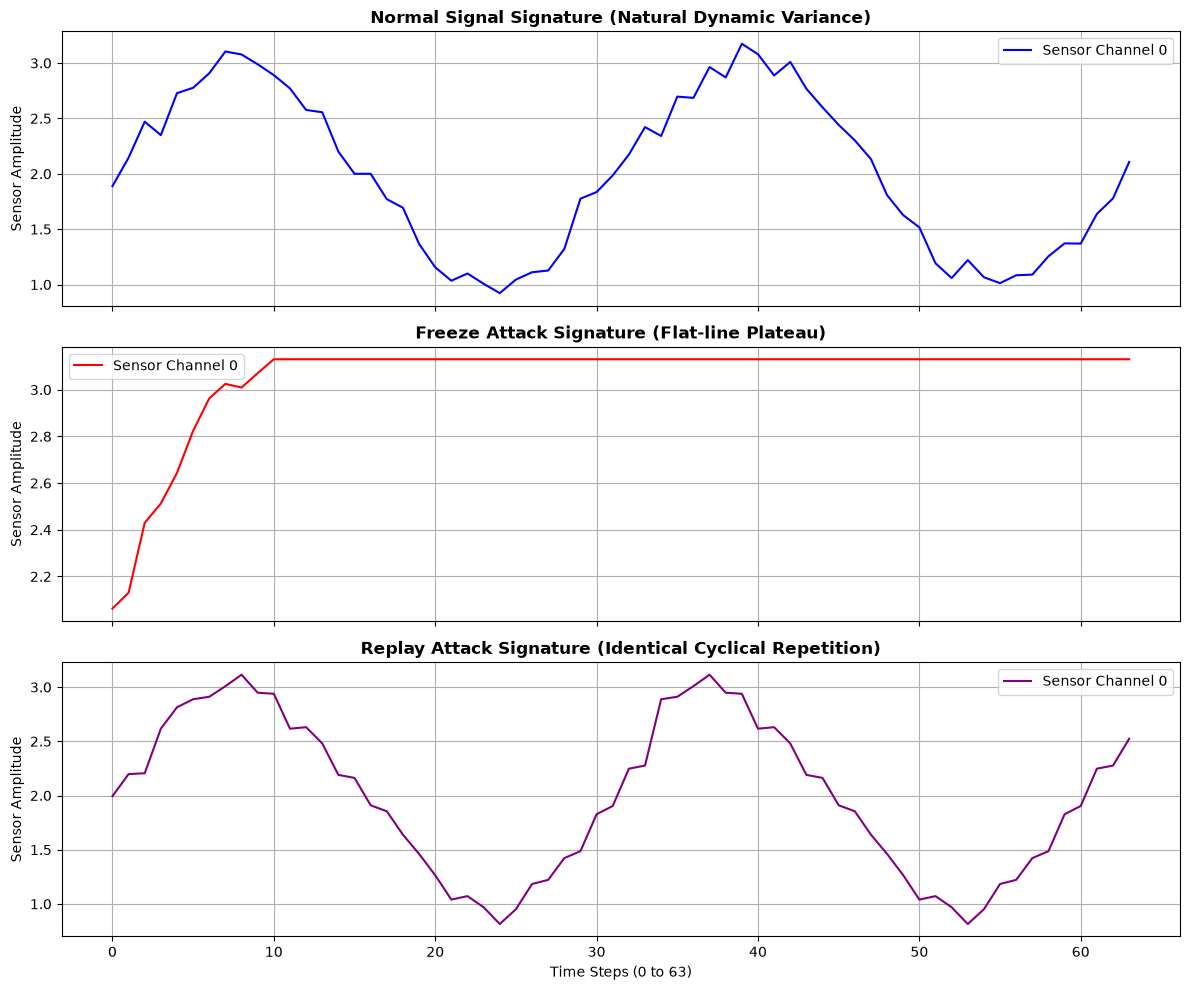

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Configuration & Loading
data_path = r"C:\Users\ACER\tinyml-iot-security\data\synthetic_L64.csv"
print(f"Reading dataset from: {data_path}")
df = pd.read_csv(data_path)

# 2. Check Class Balance
print("\n=== CLASS DISTRIBUTION ANALYSIS ===")
class_counts = df['label'].value_counts().sort_index()
class_mapping = {0: "Nominal (Normal)", 1: "Freeze Attack", 2: "Replay Attack"}

for label, count in class_counts.items():
    percentage = (count / len(df)) * 100
    print(f"Class {label} [{class_mapping[label]}]: {count} samples ({percentage:.1f}%)")

# 3. Reshape Data for Visualizing Windows
# Extract features, drop label column, reshape to matrix form: (Samples, 64 Timesteps, 5 Channels)
X_raw = df.drop(columns=['label']).values
X_windows = X_raw.reshape(-1, 64, 5)
y_labels = df['label'].values

# 4. Plot Sample Windows to Visually Map Anomalies
print("\nGenerating visual signature plots...")
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Find first occurrence index for each state
idx_normal = np.where(y_labels == 0)[0][0]
idx_freeze = np.where(y_labels == 1)[0][0]
idx_replay = np.where(y_labels == 2)[0][0]

# Plot Normal Signal (Natural Variation)
axes[0].plot(X_windows[idx_normal][:, 0], label='Sensor Channel 0', color='blue')
axes[0].set_title("Normal Signal Signature (Natural Dynamic Variance)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Sensor Amplitude")
axes[0].grid(True)
axes[0].legend()

# Plot Freeze Attack (Flat Line anomaly)
axes[1].plot(X_windows[idx_freeze][:, 0], label='Sensor Channel 0', color='red')
axes[1].set_title("Freeze Attack Signature (Flat-line Plateau)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Sensor Amplitude")
axes[1].grid(True)
axes[1].legend()

# Plot Replay Attack (Repeating Pattern anomaly)
axes[2].plot(X_windows[idx_replay][:, 0], label='Sensor Channel 0', color='purple')
axes[2].set_title("Replay Attack Signature (Identical Cyclical Repetition)", fontsize=12, fontweight='bold')
axes[2].set_xlabel("Time Steps (0 to 63)")
axes[2].set_ylabel("Sensor Amplitude")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()
